In [12]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimage
import torchvision.utils as vutils
import matplotlib.colors as c
import torch
from torch import tensor
import glob
import os
from PIL import Image
import torchvision.transforms as T
import seaborn as sns

#### Save Images Methods

In [62]:
def save_image_co(image_tensor, where, image_name, channels, savepath, single_channel_images=True):

    os.makedirs(savepath, exist_ok=True)

    cmap_R = c.LinearSegmentedColormap.from_list("cmap_R",
                                                 ['black', 'white'])  # hier sind die colormaps definiert,
    cmap_G = c.LinearSegmentedColormap.from_list("cmap_G", ['#0f0', 'white',
                                                            '#f00'])  # in denen die channel angezeigt werden
    cmap_B = c.LinearSegmentedColormap.from_list("cmap_B", ['#00f', 'white',
                                                            'yellow'])

    boundary_red = max(torch.max(image_tensor[0]), -torch.min(image_tensor[0]))

    f, axarr = plt.subplots(5, 4, figsize=(20, 20))

    img_norm = (image_tensor - torch.min(image_tensor)) / (torch.max(image_tensor) - torch.min(image_tensor))
    # img_norm = image_tensor / torch.max(image_tensor)
    axarr[0][0].imshow(img_norm.detach().cpu().permute(1, 2, 0))
    axarr[0][1].imshow(img_norm[0].detach().cpu(), cmap=cmap_R)
    vutils.save_image(img_norm, "" + savepath + "/" + image_name + "-CO.png")
    if single_channel_images:
        mpimage.imsave("" + savepath + "/" + image_name + "-bw.png", img_norm[0].detach().cpu(), cmap=cmap_R,
                   vmin=-boundary_red, vmax=boundary_red)

    if channels > 1 and single_channel_images:
        boundary_green = max(torch.max(image_tensor[1]), -torch.min(image_tensor[1]))
        boundary_blue = max(torch.max(image_tensor[2]), -torch.min(image_tensor[2]))
        axarr[0][2].imshow(img_norm[1].detach().cpu(), cmap=cmap_G)
        axarr[0][3].imshow(img_norm[2].detach().cpu(), cmap=cmap_B)
        mpimage.imsave("" + savepath + "/" + image_name + "-rg.png", img_norm[1].detach().cpu(), cmap=cmap_G,
                       vmin=-boundary_green, vmax=boundary_green)
        mpimage.imsave("" + savepath + "/" + image_name + "-bg.png", img_norm[2].detach().cpu(), cmap=cmap_B,
                       vmin=-boundary_blue, vmax=boundary_blue)

    plt.close()

def save_image_bw(image_tensor, where, image_name, channels, savepath, single_channel_images=True):


    os.makedirs(savepath, exist_ok=True)


    cmap_R = c.LinearSegmentedColormap.from_list("cmap_R",
                                                 ['black', 'white'])  # hier sind die colormaps definiert, in denen die channel angezeigt werden


    boundary_red = max(torch.max(image_tensor[0]), -torch.min(image_tensor[0]))

    f, axarr = plt.subplots(5, 4, figsize=(20, 20))

    img_norm = (image_tensor - torch.min(image_tensor)) / (torch.max(image_tensor) - torch.min(image_tensor))
    # img_norm = image_tensor / torch.max(image_tensor)
    axarr[0][0].imshow(img_norm.detach().cpu().permute(1, 2, 0))
    axarr[0][1].imshow(img_norm[0].detach().cpu(), cmap=cmap_R)
    vutils.save_image(img_norm, "" + savepath + "/" + image_name + "-GRAY.pdf")
    if single_channel_images:
        mpimage.imsave("" + savepath + "/" + image_name + "-bw.pdf", img_norm[0].detach().cpu(), cmap=cmap_R,
                   vmin=-boundary_red, vmax=boundary_red)

    if channels > 1 and single_channel_images:
        boundary_green = max(torch.max(image_tensor[1]), -torch.min(image_tensor[1]))
        boundary_blue = max(torch.max(image_tensor[2]), -torch.min(image_tensor[2]))
        axarr[0][2].imshow(img_norm[1].detach().cpu(), cmap=cmap_R)
        axarr[0][3].imshow(img_norm[2].detach().cpu(), cmap=cmap_R)
        mpimage.imsave("" + savepath + "/" + image_name + "-rg.pdf", img_norm[1].detach().cpu(), cmap=cmap_R,
                       vmin=-boundary_green, vmax=boundary_green)
        mpimage.imsave("" + savepath + "/" + image_name + "-bg.pdf", img_norm[2].detach().cpu(), cmap=cmap_R,
                       vmin=-boundary_blue, vmax=boundary_blue)

    plt.close()

def save_image_rgb(image_tensor, where, image_name, channels, savepath, single_channel_images=True):



    os.makedirs(savepath, exist_ok=True)

    # Path(path + "/" + savepath +"/" + save_name).mkdir(parents=True, exist_ok=True)

    cmap_R = c.LinearSegmentedColormap.from_list("cmap_R",
                                                 ['black', 'white', '#f00'])  # hier sind die colormaps definiert,
    cmap_G = c.LinearSegmentedColormap.from_list("cmap_G", ['black', 'white',
                                                            '#0f0'])  # in denen die channel angezeigt werden
    cmap_B = c.LinearSegmentedColormap.from_list("cmap_B", ['black', 'white', '#00f'])

    boundary_red = max(torch.max(image_tensor[0]), -torch.min(image_tensor[0]))

    f, axarr = plt.subplots(5, 4, figsize=(20, 20))

    img_norm = (image_tensor - torch.min(image_tensor)) / (torch.max(image_tensor) - torch.min(image_tensor))
    # img_norm = image_tensor / torch.max(image_tensor)
    axarr[0][0].imshow(img_norm.detach().cpu().permute(1, 2, 0))
    axarr[0][1].imshow(img_norm[0].detach().cpu(), cmap=cmap_R)
    vutils.save_image(img_norm, "" + savepath + "/" + image_name + "-RGB.png")
    if single_channel_images:
        mpimage.imsave("" + savepath + "/" + image_name + "-r.png", img_norm[0].detach().cpu(), cmap=cmap_R,
                   vmin=-boundary_red, vmax=boundary_red)

    if channels > 1 and single_channel_images:
        boundary_green = max(torch.max(image_tensor[1]), -torch.min(image_tensor[1]))
        boundary_blue = max(torch.max(image_tensor[2]), -torch.min(image_tensor[2]))
        axarr[0][2].imshow(img_norm[1].detach().cpu(), cmap=cmap_G)
        axarr[0][3].imshow(img_norm[2].detach().cpu(), cmap=cmap_B)
        mpimage.imsave("" + savepath + "/" + image_name + "-g.png", img_norm[1].detach().cpu(), cmap=cmap_G,
                       vmin=-boundary_green, vmax=boundary_green)
        mpimage.imsave("" + savepath + "/" + image_name + "-b.png", img_norm[2].detach().cpu(), cmap=cmap_B,
                       vmin=-boundary_blue, vmax=boundary_blue)

    plt.close()

## Preprocessing Code

#### Calculate Weight

In [3]:
# helper methods for preprocessing
def calculate_weight(channels, depth, single_color, color_opponency, black_white):
    weight_array = np.ones((channels, depth * 3, 1, 1))

    if depth == 1:
        if not single_color and not color_opponency and not black_white: # Average black-white image
            weight_array[:, :3, :, :] *= 1 / 3
        elif color_opponency and not single_color and not black_white: #color opponency depth 0
            weight_array[0,:,:,:] = 1/3
            for i in range(3):
                weight_array[1, i, 0, 0] = [0.5, -0.5, 0][i]
                weight_array[2, i, 0, 0] = [-0.5 / 3, -0.5 / 3, 1 / 3][i]
        elif black_white and not color_opponency and not single_color: # Luminance black-white image
            print("black_white")
            weight_array[:, 0, :, :] *= 0.299
            weight_array[:, 1, :, :] *= 0.587
            weight_array[:, 2, :, :] *= 0.114
    else:
        weight_array[:, :3, :, :] *= 1 / 3
        weight_array[:, 3:, :, :] *= -(1 / (depth * 3 - 3))

        if channels == 3 and single_color:
            print("single_color")
            for c in range(channels):
                weight_array[c, :, 0, 0] = 0  # Setze alles auf 0
                weight_array[c, c, 0, 0] = 1  # Setze die 1 an die richtige Stelle

                for i in range(1, depth):
                    weight_array[c, i * 3 + c, 0, 0] = -1 / (depth - 1)

        elif channels == 3 and color_opponency:
            print("color_opponency")
            copy = weight_array[0, :, :, :]
            weight_array = np.zeros((channels, depth * 3, 1, 1))
            weight_array[0, :, :, :] = copy
            base_r_g = [0.5, -0.5, 0]
            r_g_value = [-(1 / ((depth - 1) * 2)), (1 / ((depth - 1) * 2)), 0]
            base_b_y = [-0.5 / 3, -0.5 / 3, 1 / 3]
            b_y_value = [(0.5 / (depth * 3 - 3)), (0.5 / (depth * 3 - 3)), -(1 / (depth * 3 - 3))]

            for i in range(depth * 3):
                if i < 3:
                    # Setze die ersten drei Werte direkt auf 0.5, -0.5, 0
                    weight_array[1, i, 0, 0] = base_r_g[i]
                    weight_array[2, i, 0, 0] = base_b_y[i]
                else:
                    # Fülle den Rest mit dem Pattern entsprechend depth
                    index = (i - 3) % 3
                    weight_array[1, i, 0, 0] = r_g_value[index]
                    weight_array[2, i, 0, 0] = b_y_value[index]



    return weight_array

def create_blur_kernel():
    kernel = np.zeros((3, 3))

    for i in range(3):
        for j in range(3):
            kernel[i, j] = 1 / 9

    return kernel

#### Preprocessing Module

In [4]:
class BlurPreprocessing(nn.Module):
    def __init__(self, blur_bool, blur_depth, single_color, color_opponency, channels, path, training, black_white):
        super().__init__()
        self.blur = blur_bool
        self.num_images = blur_depth + 1
        self.single_color = single_color
        self.color_opponency = color_opponency
        self.channels = channels
        self.write = False
        self.path = path
        self.training = training
        self.black_white = black_white

        if self.blur:

            blur_kernel = create_blur_kernel()
            self.conv_blur = nn.Conv2d(3, 3 * self.num_images, 3, stride=(1, 1), padding=1, padding_mode='replicate', groups=3, bias=False)

            self.conv_blur.weight = nn.Parameter(tensor(np.array([[blur_kernel],
                                                                  [blur_kernel],
                                                                  [blur_kernel]]), requires_grad=False).float())

            for param in self.conv_blur.parameters():
                param.requires_grad = False

            self.custom_layer = nn.Conv2d(self.num_images * 3, out_channels=channels, kernel_size=1,
                                          stride=1, padding=0, bias=False)

            weight_array = calculate_weight(self.channels, self.num_images, self.single_color, self.color_opponency, self.black_white)
            self.custom_layer.weight = nn.Parameter(tensor(np.array(weight_array), requires_grad=True).float())


            # freezing the preprocessing
            for param in self.custom_layer.parameters():
                param.requires_grad = False

            self.change_channel_layer = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1, padding=0)

            print("preprocessing")
            print(self.conv_blur.weight)
            print(self.custom_layer.weight)

    def forward(self, x, save_name="image"):
        if self.blur:


            concat_image = x

            for i in range(self.num_images - 1):
                x = self.conv_blur(x)
                concat_image = torch.concat([concat_image, x], dim=1)

            x = self.custom_layer(concat_image)

            if self.channels == 1:
                x = self.change_channel_layer(x)


        if self.write:
            if(save_name=="image"):
                if(self.color_opponency):
                    save_name = "color_opponency"
                if self.single_color:
                    save_name = "single_color"
                if self.black_white:
                    save_name = "black_white"
            
            if(self.color_opponency):
                print("saving image after preprocessing")
                save_image_co(x[0], "result", save_name, self.channels, self.path, True)
            if self.single_color:
                print("saving image after preprocessing")
                save_image_rgb(x[0], "result", save_name, self.channels, self.path, True)
            if self.black_white:
                print("saving image after preprocessing")
                save_image_bw(x[0].abs(), "result", save_name, self.channels, self.path, True)
        



        return x


#### Sparsity Module

In [5]:

class SparsityPreprocessing(nn.Module):
    def __init__(self, sparsity_type, sparsity_threshold, training):
        super().__init__()
        self.sparsity_type = sparsity_type
        self.sparsity_threshold = sparsity_threshold
        self.training = training

    def forward(self, x):
        if self.sparsity_type is not None:

            if self.sparsity_type == 'percentage':
                num_elements = x.numel()
                k = int(self.sparsity_threshold * num_elements)

                if k > 0:
                    abs_vals = x.abs().flatten()
                    threshold = torch.topk(abs_vals, k, largest=False).values.max()
                    sparse_image = torch.where(x.abs() <= threshold, torch.tensor(0.0, device=x.device), x)
                    x = sparse_image
            else:
                #value based sparsity
                sparse_image = torch.where(x.abs() < self.sparsity_threshold, torch.tensor(0.0, device=x.device), x)
                x = sparse_image

                if not self.training:
                    image_pixel_number = x.numel()
                    number_of_zero_pixels = (sparse_image == 0.0).sum().item()
                    print(f"Eval: Percentage of zero pixels in the sparse image: {number_of_zero_pixels/image_pixel_number}")

        return x


## Image Generation

### Visualize Preprocessing

##### Helper

In [6]:
# Setup Modules
blur_module_bw = BlurPreprocessing(
    blur_bool=True,
    blur_depth=5,
    single_color=False,
    color_opponency=False,
    channels=3,   # 1 or 3
    path="Processed_Images/Images/bw",
    training=False,
    black_white=True
)

blur_module_rgb = BlurPreprocessing(
    blur_bool=True,
    blur_depth=5,
    single_color=True,
    color_opponency=False,
    channels=3,   # 1 or 3
    path="Processed_Images/Images/rgb",
    training=False,
    black_white=False
)

blur_module_co = BlurPreprocessing(
    blur_bool=True,
    blur_depth=5,
    single_color=False,
    color_opponency=True,
    channels=3,   # 1 or 3
    path="Processed_Images/Images/co",
    training=False,
    black_white=False
)

sparse_module_05 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None
    sparsity_threshold=0.5,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)

sparse_module_07 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None
    sparsity_threshold=0.7,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)

sparse_module_00 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None  
    sparsity_threshold=0.0,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)



transform = T.Compose([
    T.ToTensor()
])



preprocessing
Parameter containing:
tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]],


        [[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]],


        [[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]])
Parameter containing:
tensor([[[[ 0.3333]],

         [[ 0.3333]],

         [[ 0.3333]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]]],


        [[[ 0.3333]],

         [[ 0.3333]],

         [[ 0.3333]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

       

In [33]:
# helper method for visualization
def visualize_preprocessing(image_path, blur_module, sparse_module, save_name="image", save_single_channel_images=True):
    # Use CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device
    
    # Move modules to device
    blur_module = blur_module.to(device)
    sparse_module = sparse_module.to(device)
    
    # generate save name from blur module and sparsity module settings if save_name is "image"
    if save_name == "image":
        if blur_module.color_opponency:
            save_name = "color_opponency"
        elif blur_module.single_color:
            save_name = "single_color"
        elif blur_module.black_white:
            save_name = "black_white"
        
        # add blur depth to save name if blur is applied
        if blur_module.blur:
            save_name += f"_blur_depth_{blur_module.num_images}"

        if sparse_module.sparsity_type is not None:
            save_name += f"_sparsity_{sparse_module.sparsity_threshold}"

    preprocessed_image = blur_module(image_tensor, save_name)
    preprocessed_image = sparse_module(preprocessed_image)
    if not save_name == "None":
        if blur_module.black_white:
            save_image_bw(preprocessed_image[0].abs(), "result", save_name, blur_module.channels, blur_module.path, save_single_channel_images)
        if blur_module.color_opponency:
            save_image_co(preprocessed_image[0], "result", save_name, blur_module.channels, blur_module.path, save_single_channel_images)
        if blur_module.single_color:
            save_image_rgb(preprocessed_image[0], "result", save_name, blur_module.channels, blur_module.path, save_single_channel_images)
    return preprocessed_image

In [8]:
# helper method for plotting tensors
def plot_tensor_as_image(tensor_image, title="Image", cmap=None):
    plt.figure(figsize=(6, 6))
    if cmap:
        plt.imshow(tensor_image.detach().cpu(), cmap=cmap)
    else:
        plt.imshow(tensor_image.detach().cpu().permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [90]:
# function to plot value distribution of image as histogram with y-axis logarithmic
from turtle import title


def plot_value_distribution(tensor_image, title="Image Value Distribution", save = False, bins=256, ylim=None):
    plt.figure(figsize=(6, 3))
    sns.histplot(tensor_image.cpu().numpy().flatten(), bins=bins)#, kde=True)
    #plt.yscale('log')
    #plt.title(title)
    #plt.xlabel("Pixel Value")
    # set y scale to 2*10e7
    #plt.ylim(0,3000000)
    if ylim is not None:
        plt.ylim(0, ylim)
    
    plt.ylabel("")
    plt.show()
    #save the plot as pdf
    if save:
        plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\" + title + ".pdf", bbox_inches='tight')

#### Generation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4581258..0.6251676].


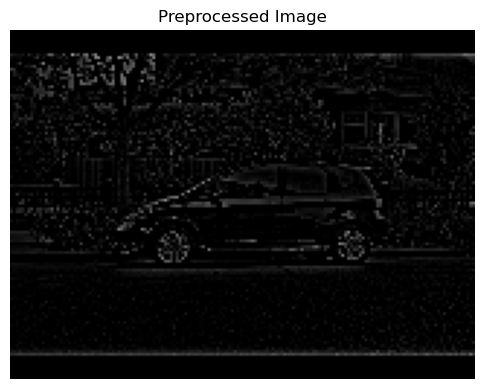

In [9]:
result = visualize_preprocessing("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\2014_000982.nef", blur_module_bw, sparse_module_00)

# plot result
plot_tensor_as_image(result[0], title="Preprocessed Image")

In [93]:
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\cityscapes.png"

original_image = Image.open(path).convert('RGB')
original_tensor = transform(original_image).unsqueeze(0)

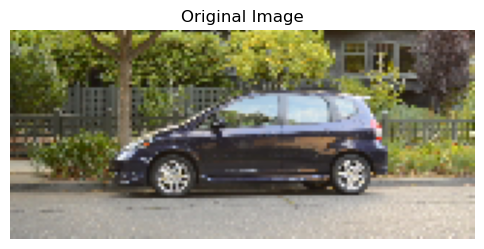

In [ ]:


# cut the original tensor top and bottom for 20% each to focus on the center part of the image
height = original_tensor.shape[2]
cut_top = int(height * 0.2)
cut_bottom = int(height * 0.8)
original_tensor = original_tensor[:, :, cut_top:cut_bottom, :]

# plot original tensor
plot_tensor_as_image(original_tensor[0], title="Original Image")

# blur image with torch gaussian blur for better visualization of sparsity
gaussian_blur = T.GaussianBlur(kernel_size=11, sigma=2.0)
#blurred_tensor = gaussian_blur(original_tensor)

# save blurred image
#save_image_rgb(blurred_tensor[0], "result", "original_blurred", 3, "images/cityscapes_blur", True)


In [94]:

original_sparse = sparse_module_07(original_tensor)
result = visualize_preprocessing(path, blur_module_bw, sparse_module_00)
result_sparse_07 = visualize_preprocessing(path, blur_module_bw, sparse_module_07)

In [86]:
# save the original image, the preprocessed image and the sparse image with sparsity 0.7 as pdfs rgb
save_image_rgb(original_tensor[0], "result", "original_image", 3, "Processed_Images/Images/sparse-figure", False)
save_image_rgb(result[0].abs(), "result", "preprocessed_image", 3, "Processed_Images/Images/sparse-figure", False)
save_image_rgb(result_sparse_07[0].abs(), "result", "sparse_image_07", 3, "Processed_Images/Images/sparse-figure", False)
save_image_rgb(original_sparse[0], "result", "original_sparse_image_07", 3, "Processed_Images/Images/sparse-figure", False)

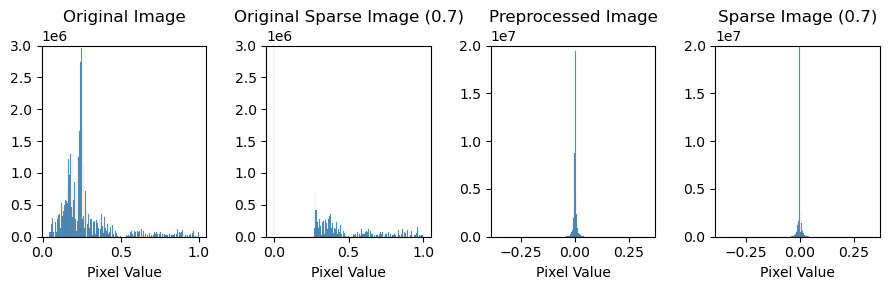

<Figure size 640x480 with 0 Axes>

In [97]:
# plot distributions of original image, original sparse, preprocessed image and sparse image with sparsity 0.7 in one row with shared y-axis
plt.figure(figsize=(9, 3))
plt.subplot(1, 4, 1)    
sns.histplot(original_tensor.cpu().numpy().flatten(), bins=256)
plt.title("Original Image")
plt.xlabel("Pixel Value")
plt.ylim(0, 3000000)
plt.ylabel("")
plt.subplot(1, 4, 2)
sns.histplot(original_sparse.cpu().numpy().flatten(), bins=256)
plt.title("Original Sparse Image (0.7)")
plt.xlabel("Pixel Value")
plt.ylim(0, 3000000)
plt.ylabel("")
plt.subplot(1, 4, 3)
sns.histplot(result.cpu().numpy().flatten(), bins=256)
plt.title("Preprocessed Image")
plt.xlabel("Pixel Value")
plt.ylim(0, 20000000)
plt.ylabel("")
plt.subplot(1, 4, 4)
sns.histplot(result_sparse_07.cpu().numpy().flatten(), bins=256)
plt.title("Sparse Image (0.7)")
plt.xlabel("Pixel Value")
plt.ylim(0, 20000000)
plt.ylabel("")
plt.tight_layout()

plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distribution_comparison.pdf", bbox_inches='tight')
plt.show()

In [96]:
# save plot as pdf
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions.pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

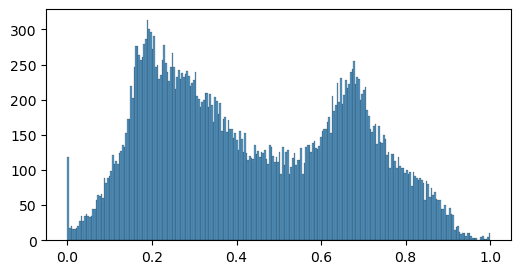

<Figure size 640x480 with 0 Axes>

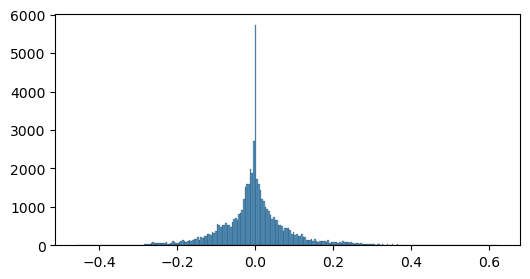

<Figure size 640x480 with 0 Axes>

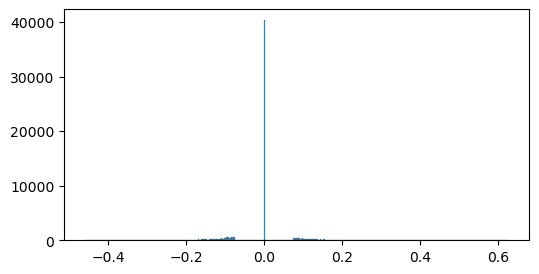

<Figure size 640x480 with 0 Axes>

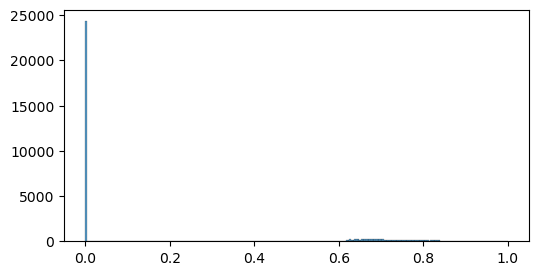

<Figure size 640x480 with 0 Axes>

In [91]:
save = True

plot_value_distribution(original_tensor, title="distribution_original", bins=256, save=save)
plot_value_distribution(result, title="distribution_preprocessed", bins=256, save=save)
plot_value_distribution(result_sparse_07, title="distribution_preprocessed_07", bins=256, save=save)
plot_value_distribution(original_sparse, title="distribution_original_07", bins=256, save=save)

##### Plotting the Distributions

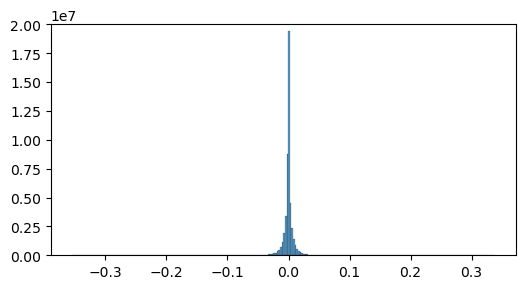

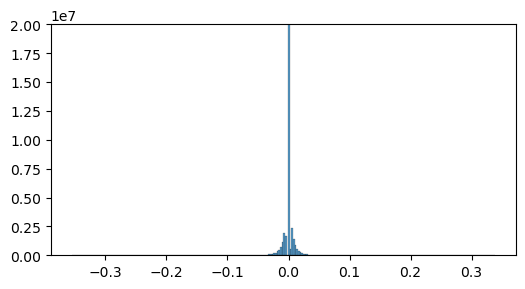

In [58]:

plot_value_distribution(result, title="Preprocessed Image Value Distribution", bins=256)
plot_value_distribution(result_sparse_05, title="Preprocessed Image with 70% Sparsity Value Distribution", bins=256)

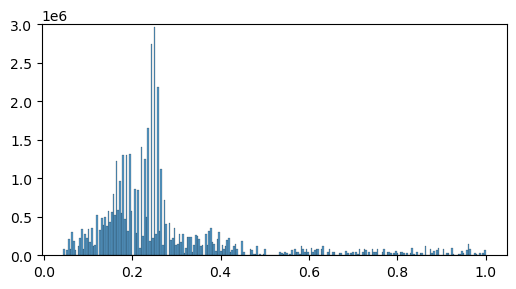

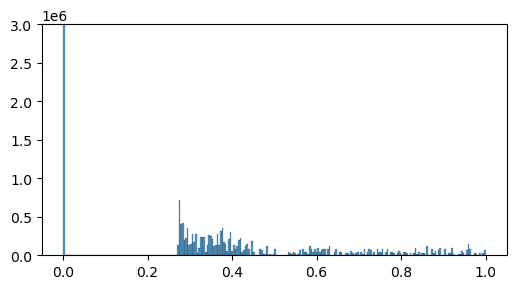

In [60]:
plot_value_distribution(original_tensor, title="Original Image Value Distribution", bins=256)
plot_value_distribution(original_sparse, title="Original Image with 70% Sparsity Value Distribution", bins=256)

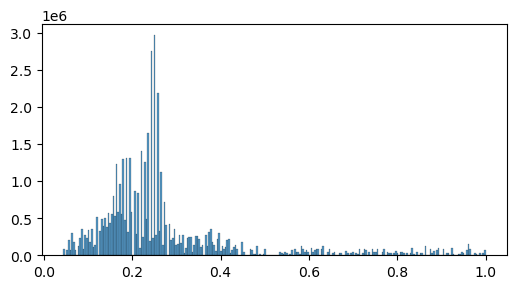

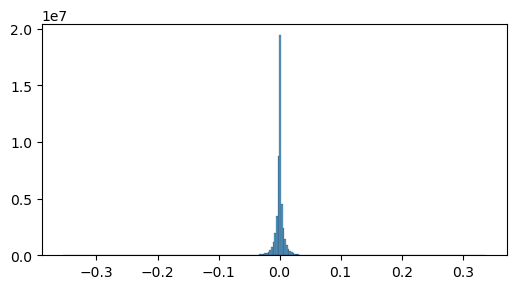

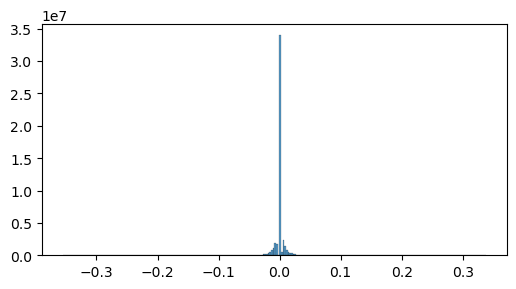

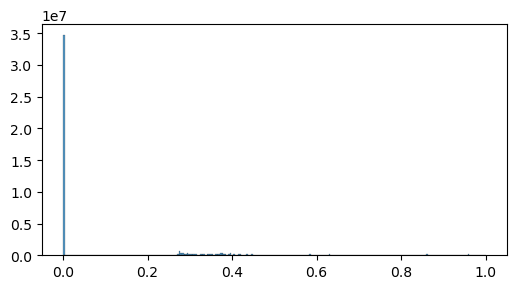

In [53]:
plot_value_distribution(original_tensor, title="Original Image Value Distribution", bins=256)
plot_value_distribution(result, title="Preprocessed Image Value Distribution", bins=256)
plot_value_distribution(result_sparse_05, title="Preprocessed Image with 70% Sparsity Value Distribution", bins=256)
plot_value_distribution(original_sparse, title="Original Image with 70% Sparsity Value Distribution", bins=256)

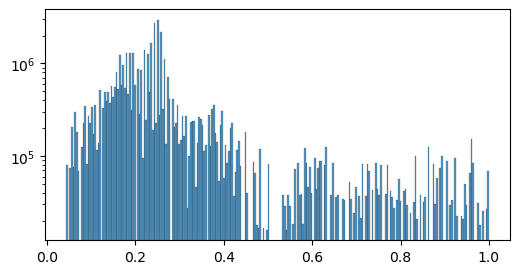

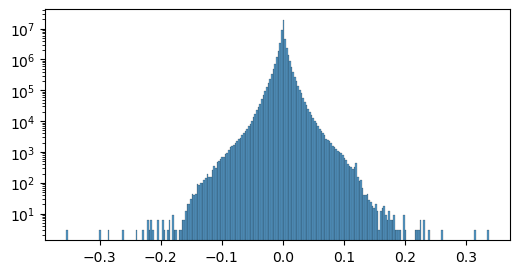

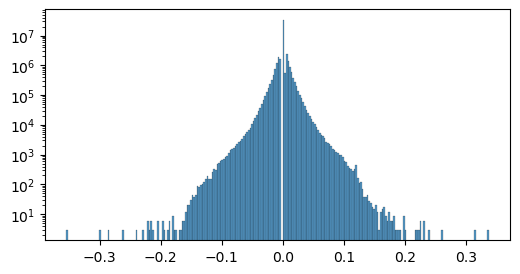

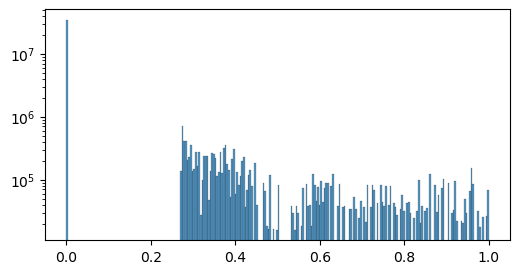

In [ ]:
plot_value_distribution(original_tensor, title="Original Image Value Distribution", bins=256)
plot_value_distribution(result, title="Preprocessed Image Value Distribution", bins=256)
plot_value_distribution(result_sparse_05, title="Preprocessed Image with 70% Sparsity Value Distribution", bins=256)
plot_value_distribution(original_sparse, title="Original Image with 70% Sparsity Value Distribution", bins=256)

##### Something else